# 07 · EDA — Censo municipal

`gold.censo_municipal_baleares` — poblacion anual por municipio (INE via IBESTAT). Solo cubre 2021-2025, por lo que **no entra como feature** en la v1 del modelo (ventana de entrenamiento 2015+).


In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
DATA = Path("data")


In [2]:
df = pl.read_csv(DATA / "censo_municipal_baleares.csv", infer_schema_length=None)
print("shape:", df.shape)
df.head(5)


shape: (335, 6)


cod_provincia_ine,nombre_provincia,cod_municipio_ine,nombre_municipio,anio,poblacion
i64,str,i64,str,i64,i64
73,"""Mallorca""",7055,"""Santa Margalida""",2022,12794
74,"""Menorca""",7037,"""Mercadal, Es""",2025,6457
73,"""Mallorca""",7033,"""Manacor""",2023,46614
73,"""Mallorca""",7031,"""Llucmajor""",2023,39156
73,"""Mallorca""",7006,"""Artà""",2023,8324


In [3]:
print("Nulos por columna:")
df.null_count()
print("anios:", sorted(df["anio"].unique().to_list()))


Nulos por columna:
anios: [2021, 2022, 2023, 2024, 2025]


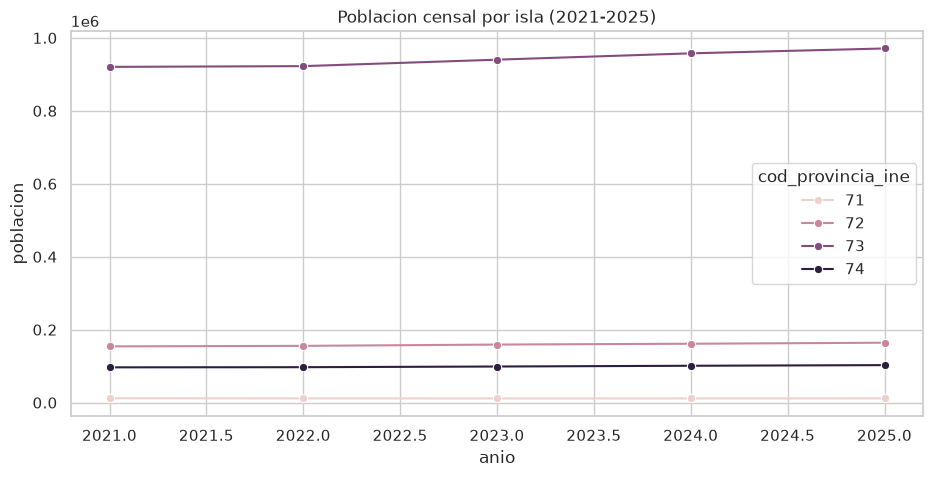

In [4]:
# Poblacion por isla (provincia 071-074)
isla_anio = df.group_by(["cod_provincia_ine", "anio"]).agg(pl.col("poblacion").sum().alias("poblacion"))
sns.lineplot(data=isla_anio.to_pandas(), x="anio", y="poblacion", hue="cod_provincia_ine", marker="o")
plt.title("Poblacion censal por isla (2021-2025)")
plt.show()


In [5]:
# Variacion interanual de la poblacion por municipio (2025 vs 2021)
piv = df.filter(pl.col("anio").is_in([2021, 2025])).pivot(
    on="anio", index=["cod_municipio_ine", "nombre_municipio"], values="poblacion"
).with_columns(
    (pl.col("2025") / pl.col("2021") - 1).alias("variacion")
)
print("municipios:", piv.height)
piv.sort("variacion", descending=True).head(10).select(["nombre_municipio", "variacion"])


municipios: 67


nombre_municipio,variacion
str,f64
"""Ariany""",0.182119
"""Mercadal, Es""",0.179576
"""Migjorn Gran, Es""",0.168651
"""Costitx""",0.156652
"""Lloret de Vistalegre""",0.155208
"""Estellencs""",0.147239
"""Sencelles""",0.127489
"""Búger""",0.121212
"""Muro""",0.111965


**Conclusiones EDA**

- Serie completa 2021-2025 (5 anios) para los 67 municipios; crecimiento generalizado.
- **No entra como feature en v1** (ventana corta vs target 2000-2024). Posible extension futura: usar como covariada en versiones del modelo que restrinjan la ventana, o como predictor exogeno.
